In [1]:
import sys
sys.path.insert(0, ".")

# ← edit these two paths
TRAJ_FILE  = "/cluster/scratch/schmiste/morph/qm9_scaffold/uncond/eval_outputs_10k_100steps_w_semla_metrics/full_metrics_20260505_062833/"  + "trajectories_valid_seed123.pt"# or trajectories_invalid_seed42.pt
TOKEN_PATH = "/cluster/project/jorner/schmiste/flexflow/chemflow/data/qm9/processed"

In [2]:
import torch
from utils import load_tokens, process_mol

mols = torch.load(TRAJ_FILE, weights_only=False)  # List[List[MoleculeData]]
atom_tokens, edge_tokens, charge_tokens, _ = load_tokens(TOKEN_PATH)

trajs = [
    [process_mol(frame, atom_tokens, charge_tokens, edge_tokens) for frame in traj]
    for traj in mols
]
print(f"Loaded {len(trajs)} trajectories, first has {len(trajs[0])} frames")

/cluster/project/jorner/schmiste/flexflow/chemflow/.venv/lib/python3.10/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: module 'torch_cluster' has no attribute 'knn'
  import torch_geometric.typing


Loaded 171 trajectories, first has 100 frames


In [41]:
traj_idx = 20  # ← change this index and re-run the cells below
print(f"Traj {traj_idx}: {len(trajs[traj_idx])} frames, "
      f"final n_atoms={len(trajs[traj_idx][-1]['atoms'])}")

Traj 20: 100 frames, final n_atoms=18


In [42]:
from utils import visualize_variable_topology_slider

visualize_variable_topology_slider(trajs[traj_idx])

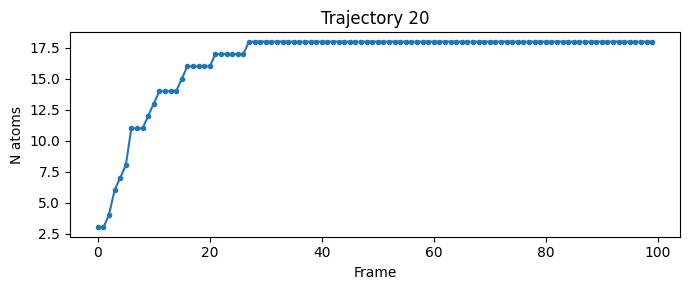

In [43]:
import matplotlib.pyplot as plt
import numpy as np

n_atoms = [len(f["atoms"]) for f in trajs[traj_idx]]
plt.figure(figsize=(7, 3))
plt.plot(n_atoms, marker="o", ms=3)
plt.xlabel("Frame")
plt.ylabel("N atoms")
plt.title(f"Trajectory {traj_idx}")
plt.tight_layout()
plt.show()

In [44]:
from utils import save_trajectory_to_sdf

save_trajectory_to_sdf(trajs, traj_idx, f"traj_{traj_idx}.sdf")

Saved 100 frames → traj_20.sdf
